In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [13]:
# import funcs

%run ./utils.ipynb

In [6]:

source = '/cosma5/data/durham/dc-pick2/simulations'

In [4]:
!tail -n 10 /cosma5/data/durham/dc-pick2/simulations/Hyades/nbody.log

         END RUN    TIME[Myr] =  626.52  TOFF/TIME/TTOT=      0.00000000    260.00000000    260.00000000  CPUTOT =   21.2  ERRTOT = 6.32360D-05  DETOT = 1.02914D-03


        0 INTEGRATION INTERVAL =  260.00    NIRR=          0 NIRRB=     120539 NREG=          0 NKS=          0


          PER TIME UNIT: NIRR= 0.00000D+00 NIRRB= 4.63612D+02 NREG= 0.00000D+00 NKS= 0.00000D+00
  MYDUMP     260.0000000000000      260                             1 
 comm.1_260                 
  Total CPU=    1270.851805061102     


In [5]:
Hyades_path = source + '/Hyades'

snaps = get_snaps(Hyades_path)
print(snaps)

['/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_0.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_100.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_120.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_140.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_160.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_180.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_200.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_20.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_220.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_40.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_60.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_80.h5part']


In [6]:
path = source + '/Hyades/snap.40_60.h5part'
with h5py.File(path, 'r') as f:
    #f.visititems(print)
    print(list(f.keys()))

['Step#0', 'Step#1', 'Step#10', 'Step#100', 'Step#101', 'Step#102', 'Step#103', 'Step#104', 'Step#105', 'Step#106', 'Step#107', 'Step#108', 'Step#109', 'Step#11', 'Step#110', 'Step#111', 'Step#112', 'Step#113', 'Step#114', 'Step#115', 'Step#116', 'Step#117', 'Step#118', 'Step#119', 'Step#12', 'Step#120', 'Step#121', 'Step#122', 'Step#123', 'Step#124', 'Step#125', 'Step#126', 'Step#127', 'Step#128', 'Step#129', 'Step#13', 'Step#130', 'Step#131', 'Step#132', 'Step#133', 'Step#134', 'Step#135', 'Step#136', 'Step#137', 'Step#138', 'Step#139', 'Step#14', 'Step#140', 'Step#141', 'Step#142', 'Step#143', 'Step#144', 'Step#145', 'Step#146', 'Step#147', 'Step#148', 'Step#149', 'Step#15', 'Step#150', 'Step#151', 'Step#152', 'Step#153', 'Step#154', 'Step#155', 'Step#156', 'Step#157', 'Step#158', 'Step#159', 'Step#16', 'Step#17', 'Step#18', 'Step#19', 'Step#2', 'Step#20', 'Step#21', 'Step#22', 'Step#23', 'Step#24', 'Step#25', 'Step#26', 'Step#27', 'Step#28', 'Step#29', 'Step#3', 'Step#30', 'Step#31

In [7]:
with h5py.File(path, 'r') as f:
    step = f['Step#159']
    print(list(step.keys()))
    x = step['X1'][:]
    y = step['X2'][:]
    z = step['X3'][:]
    m = step['M'][:]
    #kw = step['KW'][:]
    nam = kw = step['NAM'][:] # starID
    print(dict(step.attrs))


['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
{'N_SINGLE': np.int32(8462), 'Time': np.float64(80.0)}


In [8]:
path = Hyades_path + '/snap.40_240.h5part'

with h5py.File(path, 'r') as f:
    for step in sorted(f.keys(), key=lambda k: f[k].attrs['Time']):
        keys = list(f[step].keys())
        n = len(f[step]['M'])
        t = f[step].attrs['Time']
        print(f"{step}: time:{t}, {n} particles, fields: {keys}")

Step#0: time:240.125, 8460 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#1: time:240.25, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#2: time:240.375, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#3: time:240.5, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#4: time:240.625, 8458 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#5: time:240.75, 8456 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#6: time:240.875, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#7: time:241.0, 8458 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#8: time:241.125, 8460 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3'

In [7]:
Hyades_path = source + '/Hyades'
glob_path = Hyades_path + '/global.30'
df_glob = pd.read_csv(glob_path, sep=r"\s+", index_col=False)

snaps = get_snaps(Hyades_path)

snap_df = get_run_snap_times('Hyades', snaps, df_glob)
snap_df

/tmp/ipykernel_2761848/3125247750.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_glob = pd.read_csv(glob_path, sep=r"\s+", index_col=False)


,Step,Time[NB],Time[Myr],snap_path,snap_name,run
0,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
1,Step#1,0.125,0.301211,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
2,Step#2,0.250,0.602422,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
3,Step#3,0.375,0.903633,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
4,Step#4,0.500,1.204844,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
...,...,...,...,...,...,...
1596,Step#155,259.500,625.313983,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1597,Step#156,259.625,625.615194,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1598,Step#157,259.750,625.916405,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1599,Step#158,259.875,626.217616,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades


In [12]:
df_glob['TIME[Myr]'].iloc[-1] / df_glob['TIME[NB}'].iloc[-1]

np.float64(2.4096877971719843)

In [14]:
get_Myr_per_Nbody(Hyades_path)

2.4096877971719843

In [10]:
times = [0,100,200,300,400,500]
run = 'Hyades'
timesdf = find_times_Myr(snap_df, run, times)
timesdf

,Step,Time[NB],Time[Myr],snap_path,snap_name,run
0,Step#0,0.0,0.000000,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
1,Step#11,41.5,100.002044,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_40.h5part,Hyades
2,Step#23,83.0,200.004087,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_80.h5part,Hyades
3,Step#35,124.5,300.006131,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_120.h5part,Hyades
4,Step#47,166.0,400.008174,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_160.h5part,Hyades
5,Step#59,207.5,500.010218,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_200.h5part,Hyades


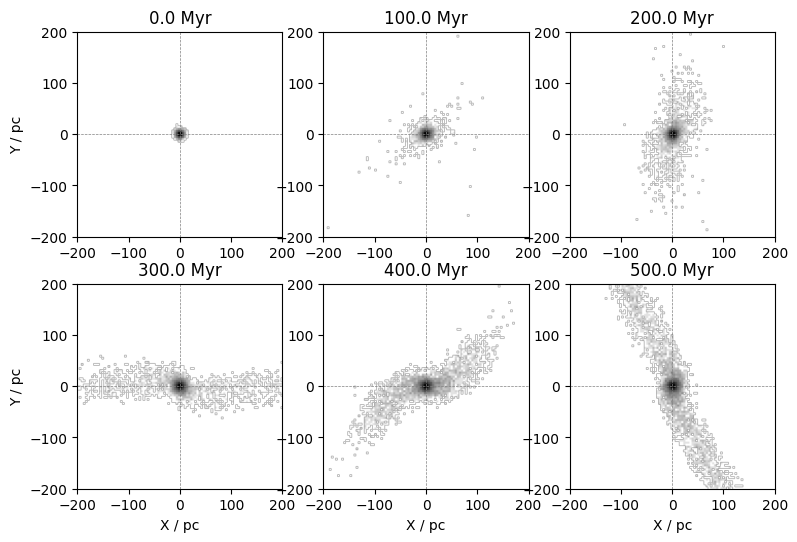

In [11]:
pltx = 3
plty = 2
offset = 200

fig, axes = plt.subplots(plty, pltx, figsize=(9, 6))
for i, row in timesdf.iterrows():
    x = i % pltx
    y = i // pltx
    ax = axes[y][x]

    Myr_per_Nbody = 1 if row['Time[NB]'] == 0 else row['Time[Myr]'] / row['Time[NB]']

    plot_step(fig, ax, row['snap_path'], row['Step'], Myr_per_Nbody, offset, 
              hidexlbl=y==0, hideylbl=x>0)

    

plt.show()

# look into z 



## Concentration

In [5]:
times = [0,100,200,300,400,500,600]
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)
runs = runs_data.keys()

/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length o

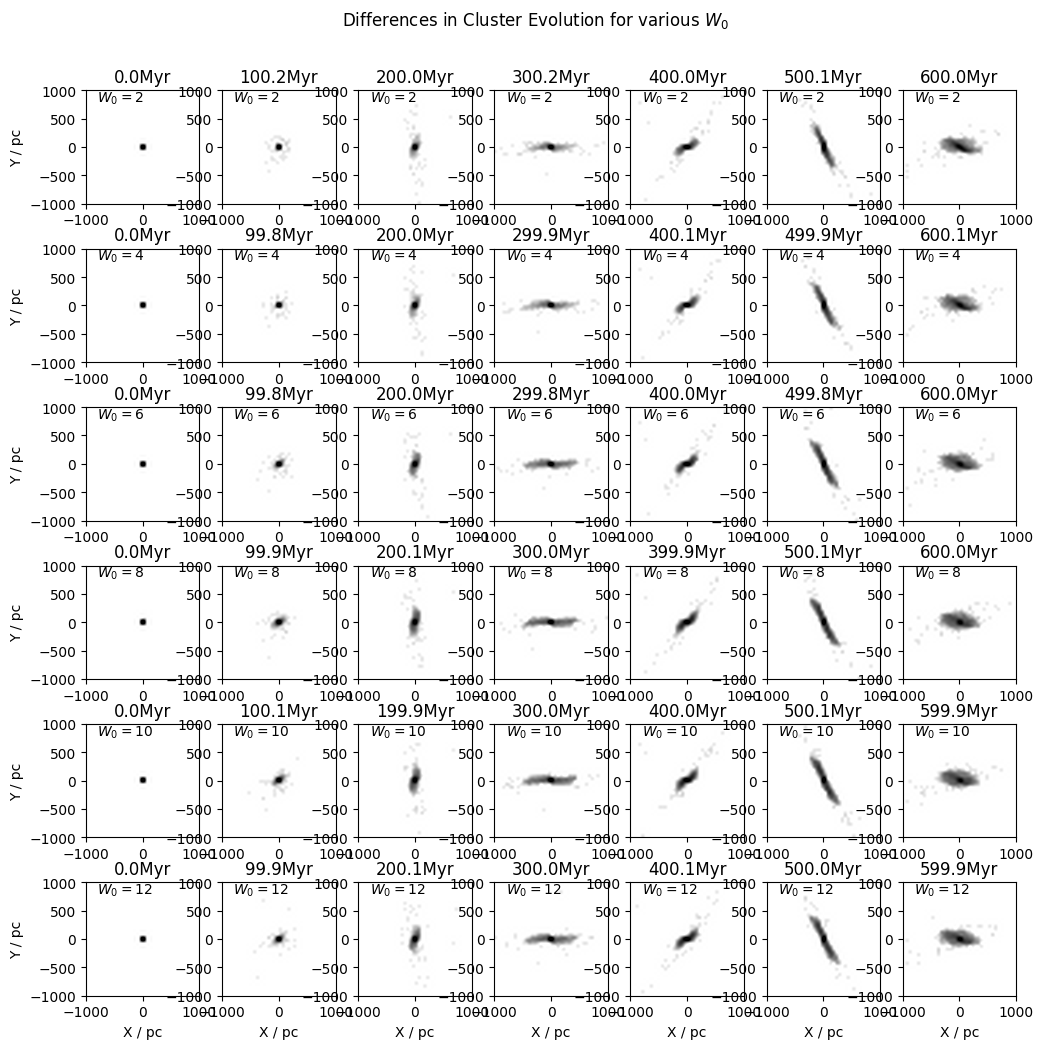

In [7]:
fig, axes = plt.subplots(len(runs), len(times), figsize=(12, 12))
offset=1000


for i, (run, (data, _, Myr_per_Nbody)) in enumerate(runs_data.items()):
    for j, (time, df) in enumerate(data.items()):
        ax = axes[i][j]
        plot_clustergram(fig, ax, df['X'], df['Y'], offset=offset, label=fr'$W_0={{{run}}}$',
                         xlbl='X / pc' if i == len(runs)-1 else '',
                         ylbl='Y / pc' if j==0 else '',
                         title=f'{df.attrs['Time']:.1f}Myr')

plt.suptitle(r'Differences in Cluster Evolution for various $W_0$', y=0.94)
plt.show()


## Mass

In [10]:
times = [0,100,200,300,400,500,600]
experiment_path = source + '/Mass'

runs_data = get_runs_data(experiment_path, times)


/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206184/2808405432.py:27: ParserWarning: Length of header or names does not match length o

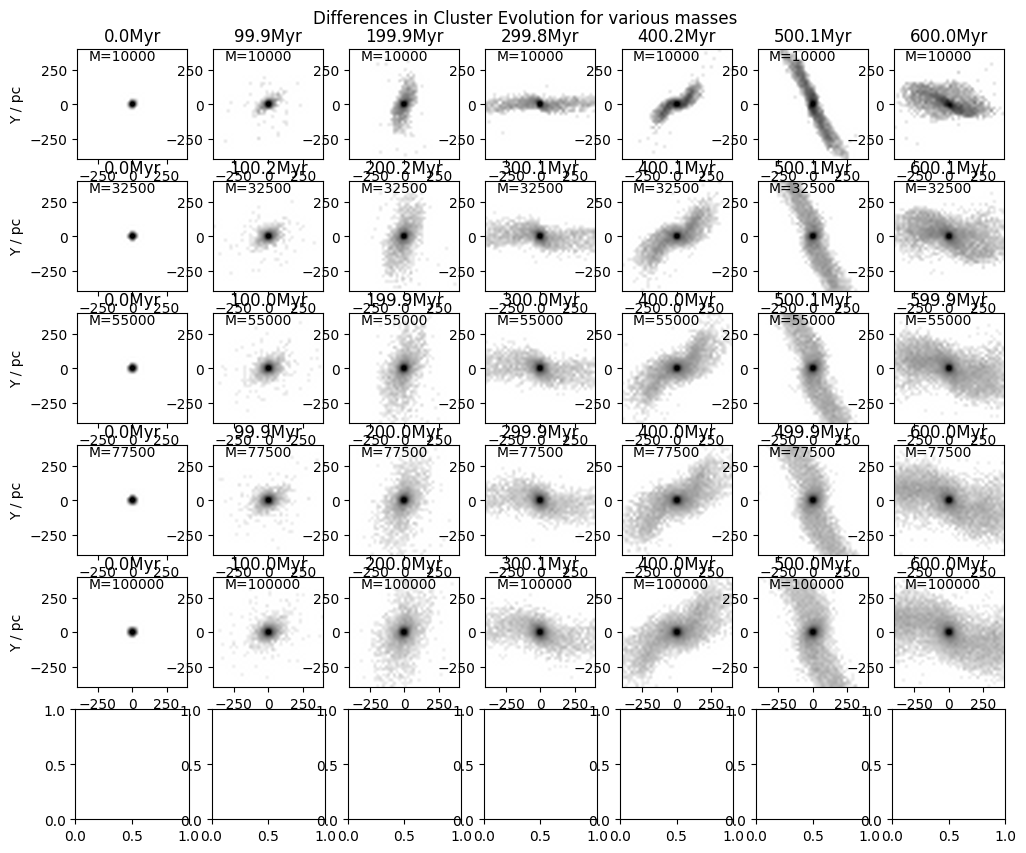

In [18]:


fig, axes = plt.subplots(len(runs), len(times), figsize=(12, 10))
offset=400


for i, (run, (data, _, Myr_per_Nbody)) in enumerate(runs_data.items()):
    for j, (time, df) in enumerate(data.items()):
        ax = axes[i][j]
        plot_clustergram(fig, ax, df['X'], df['Y'], offset=offset, label=f'M={run}',
                         xlbl='X / pc' if i == len(runs)-1 else '',
                         ylbl='Y / pc' if j==0 else '',
                         title=f'{df.attrs['Time']:.1f}Myr')

plt.suptitle(r'Differences in Cluster Evolution for various masses', y=0.92)
plt.show()
